In [1]:
import pandas as pd
from scipy.stats import zscore
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
# mixed_batch_data = pd.read_csv('/content/drive/MyDrive/curvefit_traits_merged_linearpf_onlyneccols.csv', index_col='subID')
mixed_batch_data = pd.read_csv('../../../data/subtlety_playfight_data/curvefit_traits_merged_linearpf_onlyneccols_fight.csv', index_col='subID')
mixed_batch_data.drop('Unnamed: 0', axis=1, inplace=True)
mixed_batch_data

,PSE_subt,range_subt,bias_subt,sigma_subt,PSE_pf,slope_pf,range_pf,bias_pf,social_skill,attn_switch,...,comm,posAffect,negAffect,neuroticism,extraversion,openness,agreeableness,conscientiousness,loneliness,nfriends
subID,,,,,,,,,,,,,,,,,,,,,
30002.0,0.552951,0.900821,0.315504,0.103360,0.513054,0.784286,0.784286,0.452539,21.0,23.0,...,16.000000,20.0,0.0,38.0,28.000000,31.000000,34.0,39.0,56.0,3.0
30004.0,0.276896,0.805834,0.999458,0.076866,0.872907,0.469286,0.469286,0.170256,21.0,20.0,...,15.000000,25.0,11.0,38.0,26.181818,50.000000,50.0,46.0,56.0,3.0
30005.0,0.320583,0.710131,0.861730,0.115353,0.501696,0.842143,0.842143,0.490950,17.0,29.0,...,16.000000,20.0,21.0,51.0,39.000000,40.000000,43.0,19.0,41.0,5.0
30006.0,0.464823,0.989396,0.889572,0.079221,0.741046,0.674587,0.674587,0.000307,8.0,10.0,...,3.000000,25.0,0.0,18.0,41.000000,31.000000,44.0,57.0,30.0,4.0
30008.0,0.325118,0.582252,0.692710,0.172585,0.677591,0.511071,0.511071,0.314366,5.0,15.0,...,12.222222,28.0,4.0,27.0,46.000000,42.545455,46.0,50.0,45.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30344.0,0.361233,0.655715,0.794480,0.135840,0.492859,0.566786,0.566786,0.509343,27.0,18.0,...,16.000000,14.0,0.0,25.0,29.000000,49.000000,35.0,56.0,41.0,6.0
30345.0,0.475067,0.833333,1.000000,0.013915,0.639965,0.781136,0.781136,0.000457,15.0,14.0,...,5.000000,15.0,15.0,36.0,23.000000,37.000000,45.0,54.0,72.0,1.0
30346.0,0.426850,0.999914,0.961644,0.045409,0.412504,0.786429,0.786429,0.822185,16.0,25.0,...,8.000000,27.0,6.0,49.0,36.000000,36.000000,43.0,44.0,56.0,3.0


In [3]:
mixed_batch_data = mixed_batch_data.dropna()
mixed_batch_data.shape

(274, 22)

In [4]:
mixed_batch_data['AQ_total'] = mixed_batch_data[['social_skill', 'attn_switch', 'img', 'attn_to_det', 'comm',]].sum(axis=1)
mixed_batch_data

/var/folders/n9/nm1w6x910sb0s0_nd41brq0r0000gp/T/ipykernel_79150/4228706993.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mixed_batch_data['AQ_total'] = mixed_batch_data[['social_skill', 'attn_switch', 'img', 'attn_to_det', 'comm',]].sum(axis=1)


,PSE_subt,range_subt,bias_subt,sigma_subt,PSE_pf,slope_pf,range_pf,bias_pf,social_skill,attn_switch,...,posAffect,negAffect,neuroticism,extraversion,openness,agreeableness,conscientiousness,loneliness,nfriends,AQ_total
subID,,,,,,,,,,,,,,,,,,,,,
30002.0,0.552951,0.900821,0.315504,0.103360,0.513054,0.784286,0.784286,0.452539,21.0,23.0,...,20.0,0.0,38.0,28.000000,31.000000,34.0,39.0,56.0,3.0,79.000000
30004.0,0.276896,0.805834,0.999458,0.076866,0.872907,0.469286,0.469286,0.170256,21.0,20.0,...,25.0,11.0,38.0,26.181818,50.000000,50.0,46.0,56.0,3.0,80.000000
30005.0,0.320583,0.710131,0.861730,0.115353,0.501696,0.842143,0.842143,0.490950,17.0,29.0,...,20.0,21.0,51.0,39.000000,40.000000,43.0,19.0,41.0,5.0,99.000000
30006.0,0.464823,0.989396,0.889572,0.079221,0.741046,0.674587,0.674587,0.000307,8.0,10.0,...,25.0,0.0,18.0,41.000000,31.000000,44.0,57.0,30.0,4.0,36.000000
30008.0,0.325118,0.582252,0.692710,0.172585,0.677591,0.511071,0.511071,0.314366,5.0,15.0,...,28.0,4.0,27.0,46.000000,42.545455,46.0,50.0,45.0,5.0,61.222222
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30344.0,0.361233,0.655715,0.794480,0.135840,0.492859,0.566786,0.566786,0.509343,27.0,18.0,...,14.0,0.0,25.0,29.000000,49.000000,35.0,56.0,41.0,6.0,100.000000
30345.0,0.475067,0.833333,1.000000,0.013915,0.639965,0.781136,0.781136,0.000457,15.0,14.0,...,15.0,15.0,36.0,23.000000,37.000000,45.0,54.0,72.0,1.0,53.000000
30346.0,0.426850,0.999914,0.961644,0.045409,0.412504,0.786429,0.786429,0.822185,16.0,25.0,...,27.0,6.0,49.0,36.000000,36.000000,43.0,44.0,56.0,3.0,72.000000


In [5]:
curve_param_cols = [
                  'PSE_subt',
                  'range_subt',
                  'bias_subt',
                  'range_pf',
                  'bias_pf'
                    ]
subt_param_cols = [
                  'PSE_subt',
                  'range_subt',
                  'bias_subt',
                   ]
pf_param_cols = [
                 'range_pf',
                 'bias_pf'
                 ]
trait_cols = [
              'social_skill', 'attn_switch', 'img', 'attn_to_det', 'comm',
              'posAffect',
              'negAffect',
              'neuroticism', 'extraversion', 'openness', 'agreeableness', 'conscientiousness',
              'loneliness',
              'nfriends'
       ]

social_cols = [
              'social_skill', 'attn_switch', 'img', 'attn_to_det', 'comm',
              'loneliness',
              'nfriends'
              ]

social_cols1 = [
              'AQ_total',
              'loneliness',
              'nfriends'
              ]

valence_cols = ['posAffect',
                 'negAffect',
                 'extraversion', 
                 'neuroticism'
              ]

aq =  ['social_skill', 'attn_switch', 'img', 'attn_to_det', 'comm',]

big5 = ['neuroticism', 'extraversion', 'openness', 'agreeableness', 'conscientiousness']

In [6]:
# first, super important to z-score all the features in order to minimize the impact of different features being measured on different scales (just like PCA)
mixed_batch_data_zscored = mixed_batch_data.apply(zscore)
mixed_batch_data_zscored

,PSE_subt,range_subt,bias_subt,sigma_subt,PSE_pf,slope_pf,range_pf,bias_pf,social_skill,attn_switch,...,posAffect,negAffect,neuroticism,extraversion,openness,agreeableness,conscientiousness,loneliness,nfriends,AQ_total
subID,,,,,,,,,,,,,,,,,,,,,
30002.0,1.587100,1.139946,-2.182466,0.144545,-0.206179,0.740744,0.802900,0.052813,1.249255,1.403779,...,-0.214096,-1.031925,0.328778,-1.032702,-1.533105,-1.890716,-0.771265,0.884033,-0.304004,0.723124
30004.0,-0.836964,0.619923,1.390323,-0.452518,2.089832,-0.732085,-0.731401,-0.970100,1.249255,0.813345,...,0.379919,0.470275,0.328778,-1.249254,1.402822,1.569992,0.078101,0.884033,-0.304004,0.776954
30005.0,-0.453342,0.095984,0.670868,0.414827,-0.278646,1.011263,1.084710,0.192006,0.604630,2.584649,...,-0.214096,1.835912,1.543459,0.277433,-0.142403,0.055932,-3.198024,-0.300924,0.449816,1.799723
30006.0,0.813243,1.624863,0.816307,-0.399448,1.248505,0.227830,0.268579,-1.585944,-0.845776,-1.154772,...,0.379919,-1.031925,-1.539962,0.515640,-1.533105,0.272226,1.412818,-1.169892,0.072906,-1.591563
30008.0,-0.413524,-0.604109,-0.212045,1.704615,0.843637,-0.536710,-0.527871,-0.447886,-1.329245,-0.170714,...,0.736328,-0.485670,-0.699029,1.111156,0.250927,0.704815,0.563453,0.015065,0.449816,-0.233852
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30344.0,-0.096389,-0.201924,0.319575,0.876526,-0.335034,-0.276210,-0.256498,0.258657,2.216193,0.419721,...,-0.926914,-1.031925,-0.885903,-0.913599,1.248300,-1.674422,1.291480,-0.300924,0.826726,1.853553
30345.0,0.903194,0.770473,1.393153,-1.871185,0.603566,0.726018,0.787560,-1.585402,0.282318,-0.367525,...,-0.808111,1.016530,0.141904,-1.628218,-0.605970,0.488521,1.048804,2.147987,-1.057824,-0.676454
30346.0,0.479799,1.682444,1.192794,-1.161440,-0.847731,0.750763,0.813338,1.392306,0.443474,1.797403,...,0.617525,-0.212543,1.356585,-0.079876,-0.760493,0.055932,-0.164575,0.884033,-0.304004,0.346315


In [7]:
X = mixed_batch_data_zscored[trait_cols]
X

,social_skill,attn_switch,img,attn_to_det,comm,posAffect,negAffect,neuroticism,extraversion,openness,agreeableness,conscientiousness,loneliness,nfriends
subID,,,,,,,,,,,,,,
30002.0,1.249255,1.403779,-0.345055,-1.202936,1.044306,-0.214096,-1.031925,0.328778,-1.032702,-1.533105,-1.890716,-0.771265,0.884033,-0.304004
30004.0,1.249255,0.813345,-0.345055,-0.143644,0.862296,0.379919,0.470275,0.328778,-1.249254,1.402822,1.569992,0.078101,0.884033,-0.304004
30005.0,0.604630,2.584649,2.396116,0.068214,1.044306,-0.214096,1.835912,1.543459,0.277433,-0.142403,0.055932,-3.198024,-0.300924,0.449816
30006.0,-0.845776,-1.154772,-1.258778,-1.202936,-1.321823,0.379919,-1.031925,-1.539962,0.515640,-1.533105,0.272226,1.412818,-1.169892,0.072906
30008.0,-1.329245,-0.170714,0.340238,0.280072,0.356713,0.736328,-0.485670,-0.699029,1.111156,0.250927,0.704815,0.563453,0.015065,0.449816
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30344.0,2.216193,0.419721,1.939254,0.915647,1.044306,-0.926914,-1.031925,-0.885903,-0.913599,1.248300,-1.674422,1.291480,-0.300924,0.826726
30345.0,0.282318,-0.367525,-1.030347,-0.567361,-0.957803,-0.808111,1.016530,0.141904,-1.628218,-0.605970,0.488521,1.048804,2.147987,-1.057824
30346.0,0.443474,1.797403,-0.801916,0.068214,-0.411773,0.617525,-0.212543,1.356585,-0.079876,-0.760493,0.055932,-0.164575,0.884033,-0.304004


In [8]:
y = mixed_batch_data_zscored[curve_param_cols]
y

,PSE_subt,range_subt,bias_subt,range_pf,bias_pf
subID,,,,,
30002.0,1.587100,1.139946,-2.182466,0.802900,0.052813
30004.0,-0.836964,0.619923,1.390323,-0.731401,-0.970100
30005.0,-0.453342,0.095984,0.670868,1.084710,0.192006
30006.0,0.813243,1.624863,0.816307,0.268579,-1.585944
30008.0,-0.413524,-0.604109,-0.212045,-0.527871,-0.447886
...,...,...,...,...,...
30344.0,-0.096389,-0.201924,0.319575,-0.256498,0.258657
30345.0,0.903194,0.770473,1.393153,0.787560,-1.585402
30346.0,0.479799,1.682444,1.192794,0.813338,1.392306


In [9]:
from sklearn.cross_decomposition import PLSRegression
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr
from skbio.stats.distance import mantel

# no train-test split

In [10]:
import seaborn as sns#
from sklearn.metrics import mean_squared_error

# all terms

0.27388308811629647 5.364587763872155e-25
0.07501194595611889


Text(0.5, 1.0, 'Coefficients')

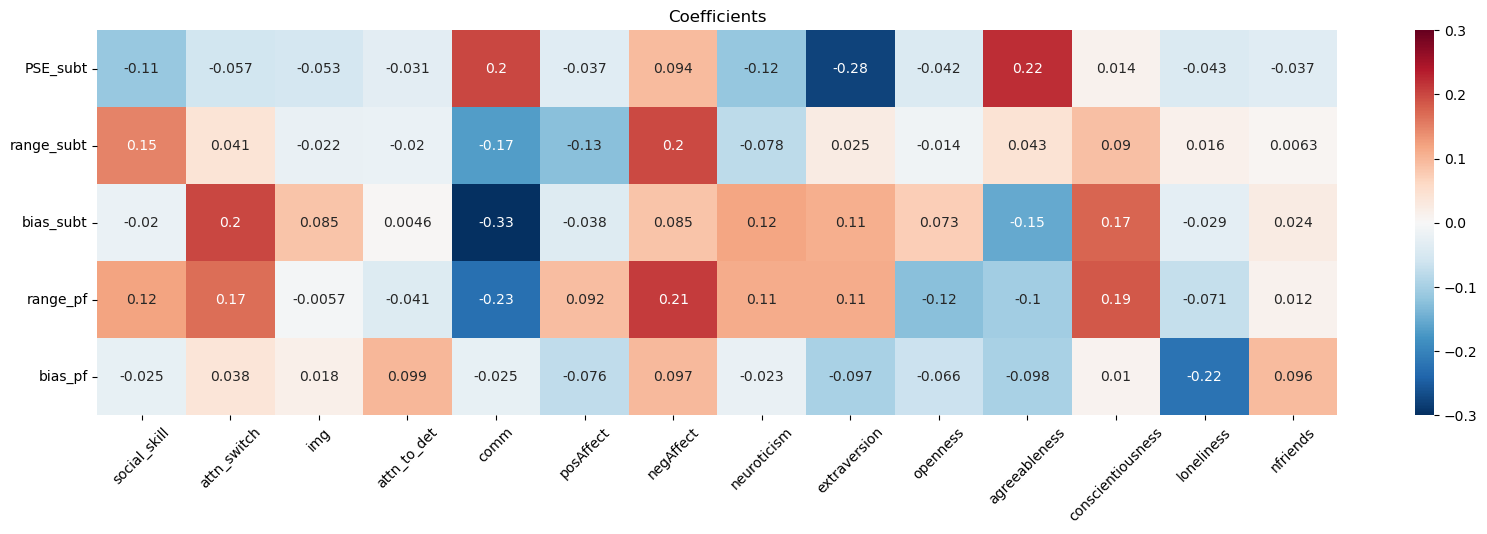

In [12]:
X = mixed_batch_data_zscored[trait_cols]
y = mixed_batch_data_zscored[curve_param_cols]  # predict curve fit params
y = y.values
X = X.values

pls = PLSRegression(n_components=X.shape[1])
pls.fit(X, y)
predicted = pls.predict(X)
r, p = pearsonr(predicted.flatten(), y.flatten())
print(r,p)
R2 = pls.score(X, y) # R2
print(R2)
mse_all_predparam = mean_squared_error(y,pls.predict(X))

fig,ax = plt.subplots(figsize=(20, 5),nrows = 1, ncols = 1)

sns.heatmap(pls.coef_, cmap = 'RdBu_r', center = 0, annot = True, ax=ax, vmin=-.3,vmax=.3)
ax.set_yticks(.5 + np.arange(len(curve_param_cols)), curve_param_cols, rotation = 0)
ax.set_xticks(.5+ np.arange(len(trait_cols)), trait_cols,rotation=45)
ax.set_title('Coefficients')


0.1374412044768163 1.2275488935772199e-17
0.018890084688037972


Text(0.5, 1.0, 'Coefficients')

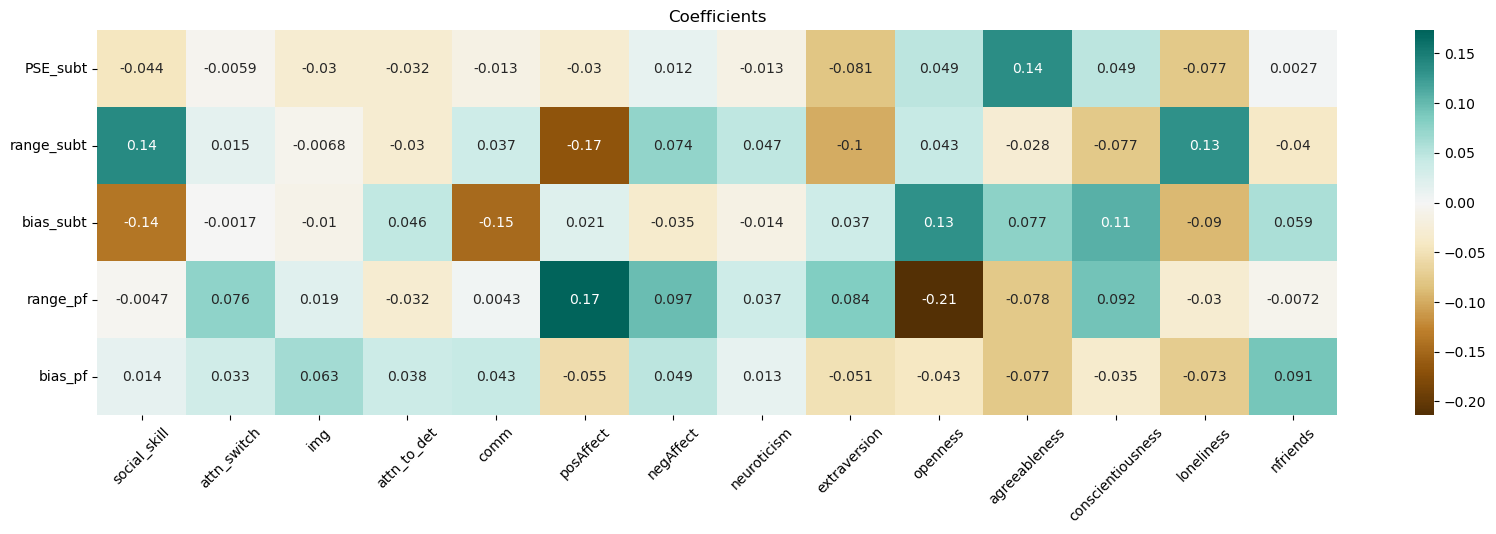

In [22]:
X = mixed_batch_data_zscored[curve_param_cols]
y = mixed_batch_data_zscored[trait_cols]  # predict traits
y = y.values
X = X.values

pls = PLSRegression(n_components=X.shape[1])
pls.fit(X, y)
predicted = pls.predict(X)
r, p = pearsonr(predicted.flatten(), y.flatten())
print(r,p)
R2 = pls.score(X, y) # R2
print(R2)
mse_all_predtrait = mean_squared_error(y,pls.predict(X))

# for comparison with above
fig,ax = plt.subplots(figsize=(20, 5),nrows = 1, ncols = 1)

sns.heatmap(pls.coef_.T, cmap = 'BrBG', center = 0, annot = True, ax=ax)
ax.set_yticks(.5 + np.arange(len(curve_param_cols)), curve_param_cols, rotation = 0)
ax.set_xticks(.5+ np.arange(len(trait_cols)), trait_cols,rotation=45)
ax.set_title('Coefficients')

# a little closer to the Pearson r's (i.e.,  means less modulation because of the other curve fit regressors?)

Text(0.5, 1.0, 'Coefficients')

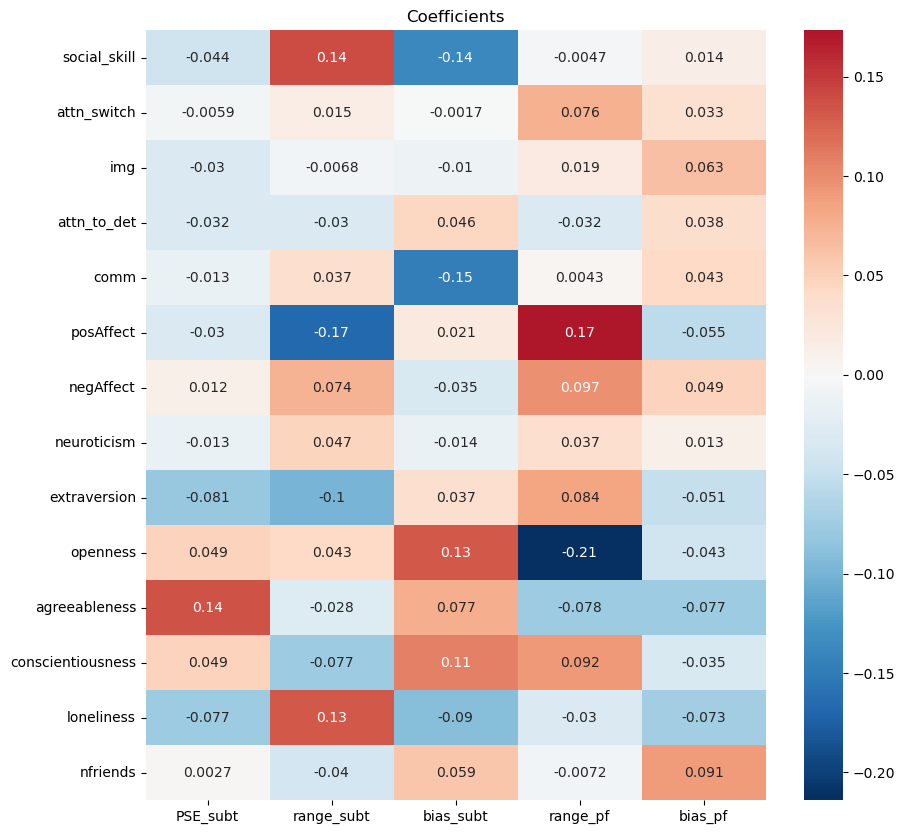

In [14]:
# actual correct plot.
fig,ax = plt.subplots(figsize=(10, 10),nrows = 1, ncols = 1)

sns.heatmap(pls.coef_, cmap = 'RdBu_r', center = 0, annot = True, ax=ax)
ax.set_xticks(.5 + np.arange(len(curve_param_cols)), curve_param_cols, rotation = 0)
ax.set_yticks(.5+ np.arange(len(trait_cols)), trait_cols,rotation=0)
ax.set_title('Coefficients')

In [15]:
mse_all_predparam, mse_all_predtrait

(np.float64(0.9249880540438813), np.float64(0.981109915311962))

## social only

0.17855444154328948 2.564528259139608e-07
0.03188168859483639


Text(0.5, 1.0, 'Coefficients')

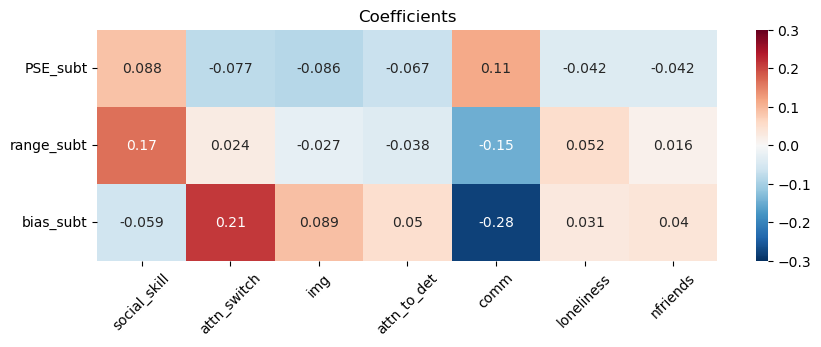

In [16]:
X = mixed_batch_data_zscored[social_cols]
y = mixed_batch_data_zscored[subt_param_cols]  # predict curve fit params
y = y.values
X = X.values

pls = PLSRegression(n_components=X.shape[1])
pls.fit(X, y)
predicted = pls.predict(X)
r, p = pearsonr(predicted.flatten(), y.flatten())
print(r,p)
R2 = pls.score(X, y) # R2
print(R2)
mse_all_pred_socparam_soctraits = mean_squared_error(y,pls.predict(X))

fig,ax = plt.subplots(figsize=(10, 3),nrows = 1, ncols = 1)

sns.heatmap(pls.coef_, cmap = 'RdBu_r', center = 0, annot = True, ax=ax, vmin=-.3,vmax=.3)
ax.set_yticks(.5 + np.arange(len(subt_param_cols)), subt_param_cols, rotation = 0)
ax.set_xticks(.5+ np.arange(len(social_cols)), social_cols,rotation=45)
ax.set_title('Coefficients')


0.26362874993612156 1.551647593404128e-14
0.06950011779288205


Text(0.5, 1.0, 'Coefficients')

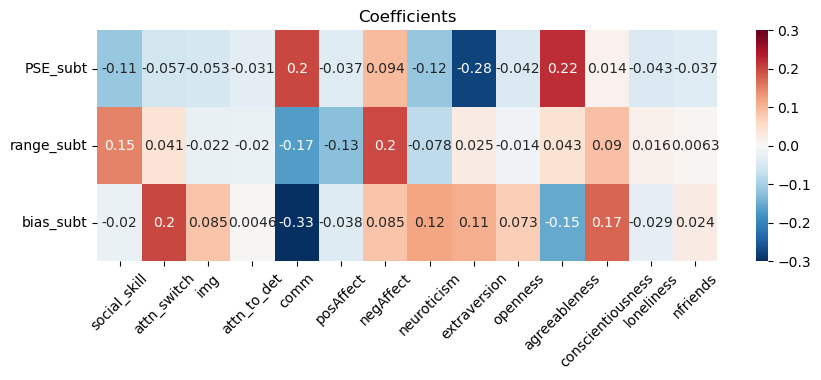

In [19]:
X = mixed_batch_data_zscored[trait_cols]
y = mixed_batch_data_zscored[subt_param_cols]  # predict curve fit params
y = y.values
X = X.values

pls = PLSRegression(n_components=X.shape[1])
pls.fit(X, y)
predicted = pls.predict(X)
r, p = pearsonr(predicted.flatten(), y.flatten())
print(r,p)
R2 = pls.score(X, y) # R2
print(R2)
mse_all_pred_socparam_alltraits = mean_squared_error(y,pls.predict(X))

fig,ax = plt.subplots(figsize=(10, 3),nrows = 1, ncols = 1)

sns.heatmap(pls.coef_, cmap = 'RdBu_r', center = 0, annot = True, ax=ax, vmin=-.3,vmax=.3)
ax.set_yticks(.5 + np.arange(len(subt_param_cols)), subt_param_cols, rotation = 0)
ax.set_xticks(.5+ np.arange(len(trait_cols)), trait_cols,rotation=45)
ax.set_title('Coefficients')


0.14786700062850414 0.0005152866952070245
0.02186464987487069


Text(0.5, 1.0, 'Coefficients')

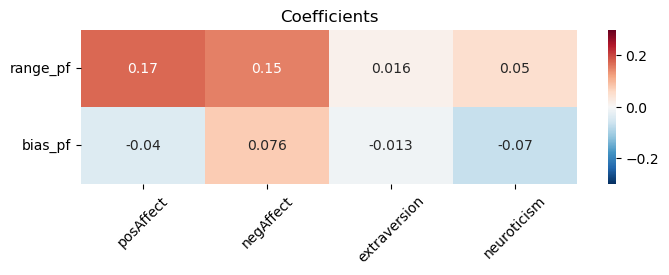

In [17]:
X = mixed_batch_data_zscored[valence_cols]
y = mixed_batch_data_zscored[pf_param_cols]  # predict curve fit params
y = y.values
X = X.values

pls = PLSRegression(n_components=X.shape[1])
pls.fit(X, y)
predicted = pls.predict(X)
r, p = pearsonr(predicted.flatten(), y.flatten())
print(r,p)
R2 = pls.score(X, y) # R2
print(R2)
mse_all_pred_pfparam_valencetraits = mean_squared_error(y,pls.predict(X))

fig,ax = plt.subplots(figsize=(8, 2),nrows = 1, ncols = 1)

sns.heatmap(pls.coef_, cmap = 'RdBu_r', center = 0, annot = True, ax=ax, vmin=-.3,vmax=.3)
ax.set_yticks(.5 + np.arange(len(pf_param_cols)), pf_param_cols, rotation = 0)
ax.set_xticks(.5+ np.arange(len(valence_cols)), valence_cols,rotation=45)
ax.set_title('Coefficients')


0.2885822035416846 5.691297337204311e-12
0.08327968820097442


Text(0.5, 1.0, 'Coefficients')

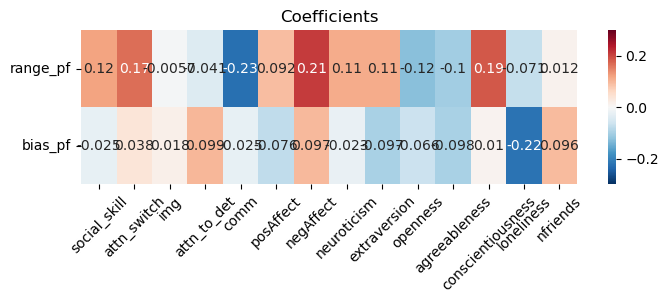

In [20]:
X = mixed_batch_data_zscored[trait_cols]
y = mixed_batch_data_zscored[pf_param_cols]  # predict curve fit params
y = y.values
X = X.values

pls = PLSRegression(n_components=X.shape[1])
pls.fit(X, y)
predicted = pls.predict(X)
r, p = pearsonr(predicted.flatten(), y.flatten())
print(r,p)
R2 = pls.score(X, y) # R2
print(R2)
mse_all_pred_pfparam_alltraits = mean_squared_error(y,pls.predict(X))

fig,ax = plt.subplots(figsize=(8, 2),nrows = 1, ncols = 1)

sns.heatmap(pls.coef_, cmap = 'RdBu_r', center = 0, annot = True, ax=ax, vmin=-.3,vmax=.3)
ax.set_yticks(.5 + np.arange(len(pf_param_cols)), pf_param_cols, rotation = 0)
ax.set_xticks(.5+ np.arange(len(trait_cols)), trait_cols,rotation=45)
ax.set_title('Coefficients')


In [21]:
mse_all_predparam, mse_all_pred_socparam_soctraits, mse_all_pred_socparam_alltraits, mse_all_pred_pfparam_valencetraits, mse_all_pred_pfparam_alltraits

(np.float64(0.9249880540438813),
 np.float64(0.9681183114051638),
 np.float64(0.9304998822071181),
 np.float64(0.9781353501251293),
 np.float64(0.9167203117990256))

# with train-test split

# all traits and all curve fit params

### predict curve fit params

In [12]:
n_perm = 1000

(TtestResult(statistic=np.float64(50.33171199430012), pvalue=np.float64(3.1872470977990317e-276), df=np.int64(999)),
 np.float64(0.07565324486320593))

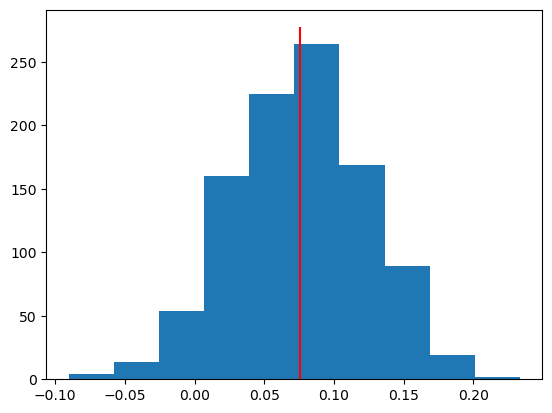

In [ ]:
X = mixed_batch_data_zscored[trait_cols]
y = mixed_batch_data_zscored[curve_param_cols]  # predict curve fit params

y = y.values
X = X.values

true_r_all = []
true_p_all = []

for i in range(n_perm):
    X_train, X_test, y_train, y_test = train_test_split(X, y) # 75-25 split by default

    pls = PLSRegression(n_components=X_train.shape[1]) # 14
    pls.fit(X_train, y_train)
    predicted = pls.predict(X_test)
    r, p = pearsonr(predicted.flatten(), y_test.flatten())
    true_r_all.append(r)
    true_p_all.append(p)
plt.hist(true_r_all)
plt.vlines(np.mean(true_r_all), 0, plt.gca().get_ylim()[1], color='red')
stats.ttest_1samp(true_r_all, 0), np.nanmean(true_r_all)

### with permutation testing

Paired t-test: TtestResult(statistic=np.float64(34.307784130083945), pvalue=np.float64(4.519265701299724e-171), df=np.int64(999))


np.float64(0.08591408591408592)

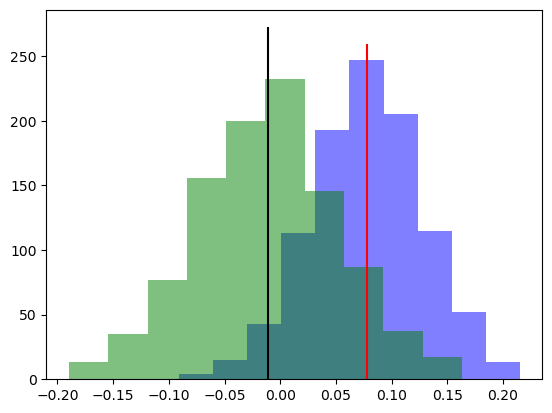

In [105]:
X = mixed_batch_data_zscored[trait_cols]
y = mixed_batch_data_zscored[curve_param_cols]  # predict curve fit params

y = y.values
X = X.values

true_r_all = []
true_p_all = []
scr_r_all = []
scr_p_all = []
for i in range(n_perm):
    X_train, X_test, y_train, y_test = train_test_split(X, y) # 75-25 split by default
    # print('X_train.shape[1]',X_train.shape[1])
    pls = PLSRegression(n_components=X_train.shape[1]) # 14
    pls.fit(X_train, y_train)
    predicted = pls.predict(X_test)
    r, p = pearsonr(predicted.flatten(), y_test.flatten())
    true_r_all.append(r)
    true_p_all.append(p)

    np.random.shuffle(y_train)
    pls = PLSRegression(n_components=X_train.shape[1])
    pls.fit(X_train, y_train)
    predicted = pls.predict(X_test)
    # predicted.shape, y_test.shape
    r,p = pearsonr(predicted.flatten(), y_test.flatten())
    scr_r_all.append(r)
    scr_p_all.append(p)

plt.hist(true_r_all, color = 'b', alpha = 0.5)
plt.hist(scr_r_all, color = 'g', alpha = 0.5)

plt.vlines(np.mean(true_r_all), 0, plt.gca().get_ylim()[1], color='r')
plt.vlines(np.mean(scr_r_all), 0, plt.gca().get_ylim()[1], color= 'k')

print('Paired t-test:', stats.ttest_rel(true_r_all, scr_r_all))

p_val = (np.sum(np.array(scr_r_all) >= np.nanmean(np.array(true_r_all))) + 1) / (n_perm + 1)
p_val

## Predict traits

(TtestResult(statistic=np.float64(-16.338479677754375), pvalue=np.float64(2.3175458164485813e-53), df=np.int64(999)),
 np.float64(-0.023096165284754448))

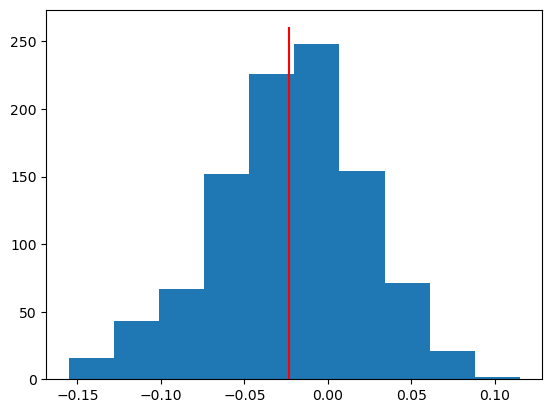

In [90]:
X = mixed_batch_data_zscored[curve_param_cols ]
y = mixed_batch_data_zscored[trait_cols]  # predict curve fit params

y = y.values
X = X.values

true_r_all = []
true_p_all = []

for i in range(1000):
    X_train, X_test, y_train, y_test = train_test_split(X, y) # 75-25 split by default

    pls = PLSRegression(n_components=X_train.shape[1]) #5
    pls.fit(X_train, y_train)
    predicted = pls.predict(X_test)
    r, p = pearsonr(predicted.flatten(), y_test.flatten())
    true_r_all.append(r)
    true_p_all.append(p)
plt.hist(true_r_all)
plt.vlines(np.mean(true_r_all), 0, plt.gca().get_ylim()[1], color='red')
stats.ttest_1samp(true_r_all, 0), np.nanmean(true_r_all)

### with permutation testing

Paired t-test: TtestResult(statistic=np.float64(-1.1222471852513967), pvalue=np.float64(0.2620270078030116), df=np.int64(999))


np.float64(0.5114885114885115)

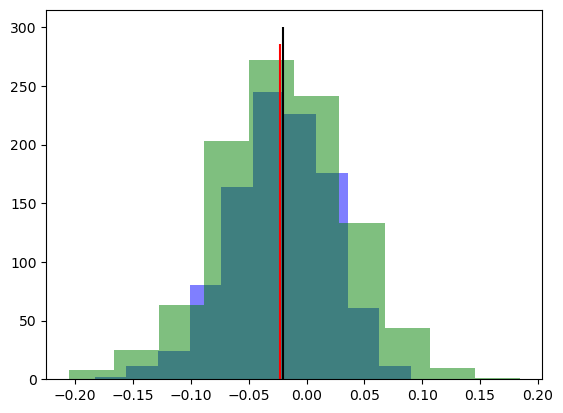

In [91]:
X = mixed_batch_data_zscored[curve_param_cols]
y = mixed_batch_data_zscored[trait_cols]  # predict curve fit params

y = y.values
X = X.values

true_r_all = []
true_p_all = []
scr_r_all = []
scr_p_all = []
for i in range(1000):
    X_train, X_test, y_train, y_test = train_test_split(X, y) # 75-25 split by default

    pls = PLSRegression(X_train.shape[1])
    pls.fit(X_train, y_train)
    predicted = pls.predict(X_test)
    r, p = pearsonr(predicted.flatten(), y_test.flatten())
    true_r_all.append(r)
    true_p_all.append(p)

    np.random.shuffle(y_train)
    pls = PLSRegression(X_train.shape[1])
    pls.fit(X_train, y_train)
    predicted = pls.predict(X_test)
    # predicted.shape, y_test.shape
    r,p = pearsonr(predicted.flatten(), y_test.flatten())
    scr_r_all.append(r)
    scr_p_all.append(p)

plt.hist(true_r_all, color = 'b', alpha = 0.5)
plt.hist(scr_r_all, color = 'g', alpha = 0.5)

plt.vlines(np.mean(true_r_all), 0, plt.gca().get_ylim()[1], color='r')
plt.vlines(np.mean(scr_r_all), 0, plt.gca().get_ylim()[1], color= 'k')

print('Paired t-test:', stats.ttest_rel(true_r_all, scr_r_all))

p_val = (np.sum(np.array(scr_r_all) >= np.nanmean(np.array(true_r_all))) + 1) / (n_perm + 1)
p_val

- From permutation testing, predicting behavior looks a little better than predicting traits

# now on, only predictions of behaviors from traits. 
# y = curve params, x =  traits

### predicting only subtlety 

#### from all traits

Paired t-test: TtestResult(statistic=np.float64(22.366396519846226), pvalue=np.float64(3.7374397190487414e-90), df=np.int64(999))


np.float64(0.1928071928071928)

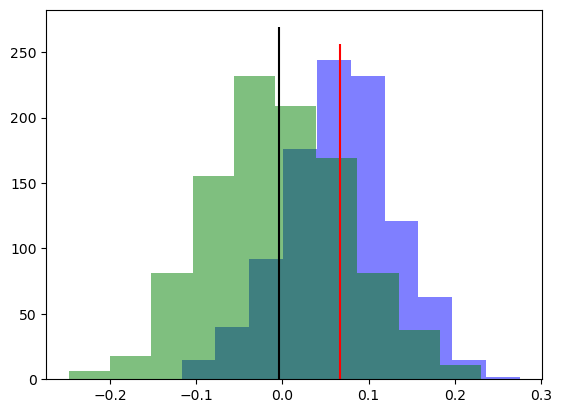

In [93]:
X = mixed_batch_data_zscored[trait_cols]
y = mixed_batch_data_zscored[subt_param_cols]  # predict curve fit params

y = y.values
X = X.values

true_r_all = []
true_p_all = []
scr_r_all = []
scr_p_all = []
for i in range(1000):
    X_train, X_test, y_train, y_test = train_test_split(X, y) # 75-25 split by default

    pls = PLSRegression(n_components=X_train.shape[1])
    pls.fit(X_train, y_train)
    predicted = pls.predict(X_test)
    r, p = pearsonr(predicted.flatten(), y_test.flatten())
    true_r_all.append(r)
    true_p_all.append(p)

    np.random.shuffle(y_train)
    pls = PLSRegression(n_components=X_train.shape[1])
    pls.fit(X_train, y_train)
    predicted = pls.predict(X_test)
    # predicted.shape, y_test.shape
    r,p = pearsonr(predicted.flatten(), y_test.flatten())
    scr_r_all.append(r)
    scr_p_all.append(p)

plt.hist(true_r_all, color = 'b', alpha = 0.5)
plt.hist(scr_r_all, color = 'g', alpha = 0.5)

plt.vlines(np.mean(true_r_all), 0, plt.gca().get_ylim()[1], color='r')
plt.vlines(np.mean(scr_r_all), 0, plt.gca().get_ylim()[1], color= 'k')

print('Paired t-test:', stats.ttest_rel(true_r_all, scr_r_all))

p_val = (np.sum(np.array(scr_r_all) >= np.nanmean(np.array(true_r_all))) + 1) / (n_perm + 1)
p_val

### predicting only subtlety 

#### from social traits

Paired t-test: TtestResult(statistic=np.float64(11.494641159741578), pvalue=np.float64(8.301635526862937e-29), df=np.int64(999))


np.float64(0.3106893106893107)

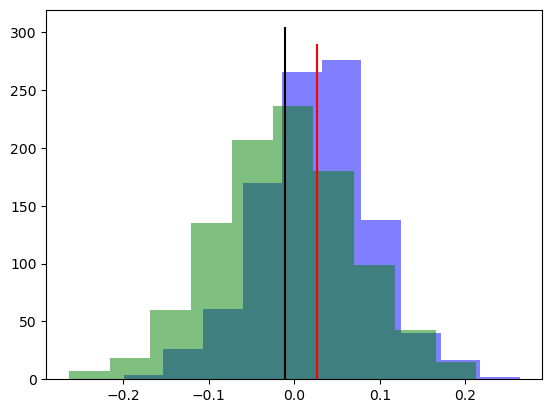

In [94]:
X = mixed_batch_data_zscored[social_cols]
y = mixed_batch_data_zscored[subt_param_cols]  # predict curve fit params

y = y.values
X = X.values

true_r_all = []
true_p_all = []
scr_r_all = []
scr_p_all = []
for i in range(1000):
    X_train, X_test, y_train, y_test = train_test_split(X, y) # 75-25 split by default

    pls = PLSRegression(n_components=X_train.shape[1])
    pls.fit(X_train, y_train)
    predicted = pls.predict(X_test)
    r, p = pearsonr(predicted.flatten(), y_test.flatten())
    true_r_all.append(r)
    true_p_all.append(p)

    np.random.shuffle(y_train)
    pls = PLSRegression(n_components=X_train.shape[1])
    pls.fit(X_train, y_train)
    predicted = pls.predict(X_test)
    # predicted.shape, y_test.shape
    r,p = pearsonr(predicted.flatten(), y_test.flatten())
    scr_r_all.append(r)
    scr_p_all.append(p)

plt.hist(true_r_all, color = 'b', alpha = 0.5)
plt.hist(scr_r_all, color = 'g', alpha = 0.5)

plt.vlines(np.mean(true_r_all), 0, plt.gca().get_ylim()[1], color='r')
plt.vlines(np.mean(scr_r_all), 0, plt.gca().get_ylim()[1], color= 'k')

print('Paired t-test:', stats.ttest_rel(true_r_all, scr_r_all))

p_val = (np.sum(np.array(scr_r_all) >= np.nanmean(np.array(true_r_all))) + 1) / (n_perm + 1)
p_val

### predicting only pf terms 

#### from all traits

Paired t-test: TtestResult(statistic=np.float64(32.10710923848386), pvalue=np.float64(5.645762467576922e-156), df=np.int64(999))


np.float64(0.1068931068931069)

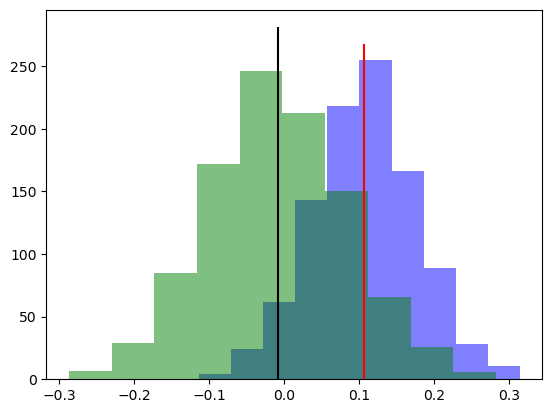

In [97]:
X = mixed_batch_data_zscored[trait_cols]
y = mixed_batch_data_zscored[pf_param_cols]  # predict curve fit params

y = y.values
X = X.values

true_r_all = []
true_p_all = []
scr_r_all = []
scr_p_all = []
for i in range(1000):
    X_train, X_test, y_train, y_test = train_test_split(X, y) # 75-25 split by default

    pls = PLSRegression(n_components=X_train.shape[1])
    pls.fit(X_train, y_train)
    predicted = pls.predict(X_test)
    r, p = pearsonr(predicted.flatten(), y_test.flatten())
    true_r_all.append(r)
    true_p_all.append(p)

    np.random.shuffle(y_train)
    pls = PLSRegression(n_components=X_train.shape[1])
    pls.fit(X_train, y_train)
    predicted = pls.predict(X_test)
    # predicted.shape, y_test.shape
    r,p = pearsonr(predicted.flatten(), y_test.flatten())
    scr_r_all.append(r)
    scr_p_all.append(p)

plt.hist(true_r_all, color = 'b', alpha = 0.5)
plt.hist(scr_r_all, color = 'g', alpha = 0.5)

plt.vlines(np.mean(true_r_all), 0, plt.gca().get_ylim()[1], color='r')
plt.vlines(np.mean(scr_r_all), 0, plt.gca().get_ylim()[1], color= 'k')

print('Paired t-test:', stats.ttest_rel(true_r_all, scr_r_all))

p_val = (np.sum(np.array(scr_r_all) >= np.nanmean(np.array(true_r_all))) + 1) / (n_perm + 1)
p_val

### predicting only pf 

#### from valence traits

Paired t-test: TtestResult(statistic=np.float64(16.554682596343074), pvalue=np.float64(1.3975171767955828e-54), df=np.int64(999))


np.float64(0.26873126873126874)

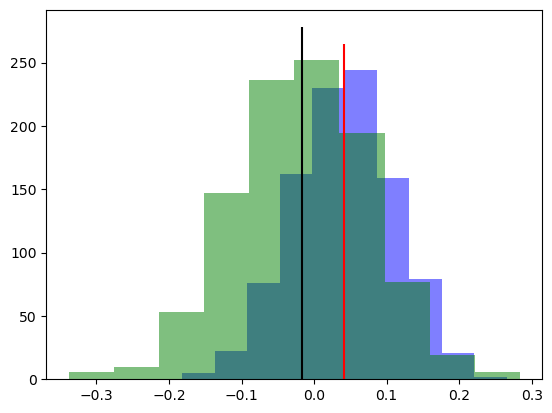

In [98]:
X = mixed_batch_data_zscored[valence_cols]
y = mixed_batch_data_zscored[pf_param_cols]  # predict curve fit params

y = y.values
X = X.values

true_r_all = []
true_p_all = []
scr_r_all = []
scr_p_all = []
for i in range(1000):
    X_train, X_test, y_train, y_test = train_test_split(X, y) # 75-25 split by default

    pls = PLSRegression(n_components=X_train.shape[1])
    pls.fit(X_train, y_train)
    predicted = pls.predict(X_test)
    r, p = pearsonr(predicted.flatten(), y_test.flatten())
    true_r_all.append(r)
    true_p_all.append(p)

    np.random.shuffle(y_train)
    pls = PLSRegression(n_components=X_train.shape[1])
    pls.fit(X_train, y_train)
    predicted = pls.predict(X_test)
    # predicted.shape, y_test.shape
    r,p = pearsonr(predicted.flatten(), y_test.flatten())
    scr_r_all.append(r)
    scr_p_all.append(p)

plt.hist(true_r_all, color = 'b', alpha = 0.5)
plt.hist(scr_r_all, color = 'g', alpha = 0.5)

plt.vlines(np.mean(true_r_all), 0, plt.gca().get_ylim()[1], color='r')
plt.vlines(np.mean(scr_r_all), 0, plt.gca().get_ylim()[1], color= 'k')

print('Paired t-test:', stats.ttest_rel(true_r_all, scr_r_all))

p_val = (np.sum(np.array(scr_r_all) >= np.nanmean(np.array(true_r_all))) + 1) / (n_perm + 1)
p_val

## big 5

In [153]:
curve_param_cols

['PSE_subt', 'range_subt', 'bias_subt', 'range_pf', 'bias_pf']

Paired t-test: TtestResult(statistic=np.float64(32.98438079715571), pvalue=np.float64(5.342961614253429e-162), df=np.int64(999))


np.float64(0.1088911088911089)

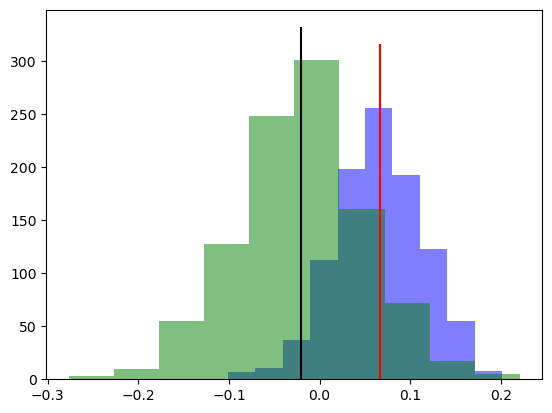

In [99]:
X = mixed_batch_data_zscored[big5]
y = mixed_batch_data_zscored[curve_param_cols]  # predict curve fit params

y = y.values
X = X.values

true_r_all = []
true_p_all = []
scr_r_all = []
scr_p_all = []
for i in range(1000):
    X_train, X_test, y_train, y_test = train_test_split(X, y) # 75-25 split by default

    pls = PLSRegression(n_components=X_train.shape[1])
    pls.fit(X_train, y_train)
    predicted = pls.predict(X_test)
    r, p = pearsonr(predicted.flatten(), y_test.flatten())
    true_r_all.append(r)
    true_p_all.append(p)

    np.random.shuffle(y_train)
    pls = PLSRegression(n_components=X_train.shape[1])
    pls.fit(X_train, y_train)
    predicted = pls.predict(X_test)
    # predicted.shape, y_test.shape
    r,p = pearsonr(predicted.flatten(), y_test.flatten())
    scr_r_all.append(r)
    scr_p_all.append(p)

plt.hist(true_r_all, color = 'b', alpha = 0.5)
plt.hist(scr_r_all, color = 'g', alpha = 0.5)

plt.vlines(np.mean(true_r_all), 0, plt.gca().get_ylim()[1], color='r')
plt.vlines(np.mean(scr_r_all), 0, plt.gca().get_ylim()[1], color= 'k')

print('Paired t-test:', stats.ttest_rel(true_r_all, scr_r_all))

p_val = (np.sum(np.array(scr_r_all) >= np.nanmean(np.array(true_r_all))) + 1) / (n_perm + 1)
p_val

#### only subt, from big 5

Paired t-test: TtestResult(statistic=np.float64(28.052770611119893), pvalue=np.float64(3.5706158662663634e-128), df=np.int64(999))


np.float64(0.15084915084915085)

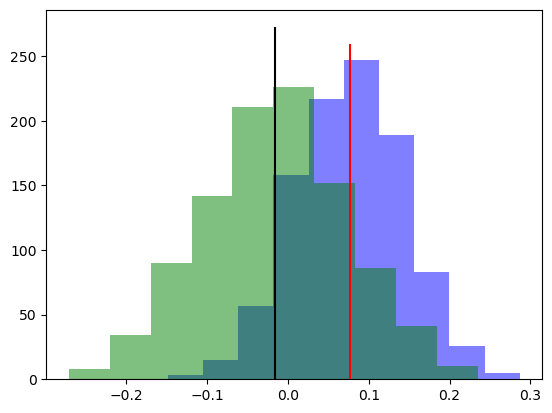

In [100]:
X = mixed_batch_data_zscored[big5]
y = mixed_batch_data_zscored[subt_param_cols]  # predict curve fit params

y = y.values
X = X.values

true_r_all = []
true_p_all = []
scr_r_all = []
scr_p_all = []
for i in range(1000):
    X_train, X_test, y_train, y_test = train_test_split(X, y) # 75-25 split by default

    pls = PLSRegression(n_components=X_train.shape[1])
    pls.fit(X_train, y_train)
    predicted = pls.predict(X_test)
    r, p = pearsonr(predicted.flatten(), y_test.flatten())
    true_r_all.append(r)
    true_p_all.append(p)

    np.random.shuffle(y_train)
    pls = PLSRegression(n_components=X_train.shape[1])
    pls.fit(X_train, y_train)
    predicted = pls.predict(X_test)
    # predicted.shape, y_test.shape
    r,p = pearsonr(predicted.flatten(), y_test.flatten())
    scr_r_all.append(r)
    scr_p_all.append(p)

plt.hist(true_r_all, color = 'b', alpha = 0.5)
plt.hist(scr_r_all, color = 'g', alpha = 0.5)

plt.vlines(np.mean(true_r_all), 0, plt.gca().get_ylim()[1], color='r')
plt.vlines(np.mean(scr_r_all), 0, plt.gca().get_ylim()[1], color= 'k')

print('Paired t-test:', stats.ttest_rel(true_r_all, scr_r_all))

p_val = (np.sum(np.array(scr_r_all) >= np.nanmean(np.array(true_r_all))) + 1) / (n_perm + 1)
p_val

### only pf, from big 5

Paired t-test: TtestResult(statistic=np.float64(22.11966556763524), pvalue=np.float64(1.478323395880489e-88), df=np.int64(999))


np.float64(0.20679320679320679)

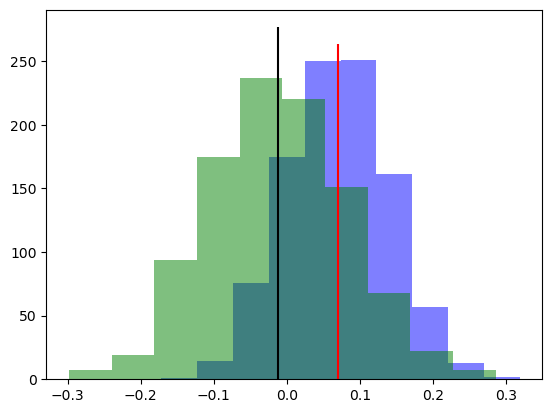

In [101]:
X = mixed_batch_data_zscored[big5]
y = mixed_batch_data_zscored[pf_param_cols]  # predict curve fit params

y = y.values
X = X.values

true_r_all = []
true_p_all = []
scr_r_all = []
scr_p_all = []
for i in range(1000):
    X_train, X_test, y_train, y_test = train_test_split(X, y) # 75-25 split by default

    pls = PLSRegression(n_components=X_train.shape[1])
    pls.fit(X_train, y_train)
    predicted = pls.predict(X_test)
    r, p = pearsonr(predicted.flatten(), y_test.flatten())
    true_r_all.append(r)
    true_p_all.append(p)

    np.random.shuffle(y_train)
    pls = PLSRegression(n_components=X_train.shape[1])
    pls.fit(X_train, y_train)
    predicted = pls.predict(X_test)
    # predicted.shape, y_test.shape
    r,p = pearsonr(predicted.flatten(), y_test.flatten())
    scr_r_all.append(r)
    scr_p_all.append(p)

plt.hist(true_r_all, color = 'b', alpha = 0.5)
plt.hist(scr_r_all, color = 'g', alpha = 0.5)

plt.vlines(np.mean(true_r_all), 0, plt.gca().get_ylim()[1], color='r')
plt.vlines(np.mean(scr_r_all), 0, plt.gca().get_ylim()[1], color= 'k')

print('Paired t-test:', stats.ttest_rel(true_r_all, scr_r_all))

p_val = (np.sum(np.array(scr_r_all) >= np.nanmean(np.array(true_r_all))) + 1) / (n_perm + 1)
p_val

### only AQ, from subt

Paired t-test: TtestResult(statistic=np.float64(22.734844940083914), pvalue=np.float64(1.5021473604843658e-92), df=np.int64(999))


np.float64(0.1888111888111888)

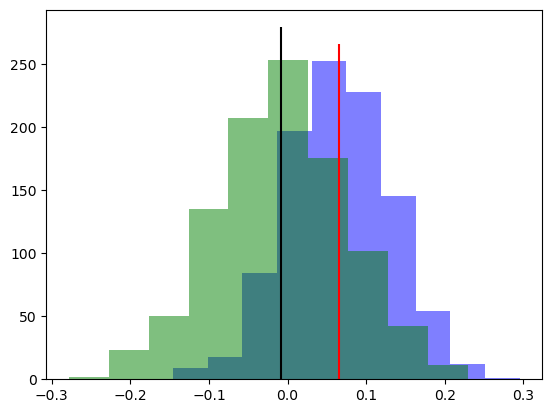

In [102]:
X = mixed_batch_data_zscored[aq]
y = mixed_batch_data_zscored[subt_param_cols]  # predict curve fit params

y = y.values
X = X.values

true_r_all = []
true_p_all = []
scr_r_all = []
scr_p_all = []
for i in range(1000):
    X_train, X_test, y_train, y_test = train_test_split(X, y) # 75-25 split by default

    pls = PLSRegression(n_components=X_train.shape[1])
    pls.fit(X_train, y_train)
    predicted = pls.predict(X_test)
    r, p = pearsonr(predicted.flatten(), y_test.flatten())
    true_r_all.append(r)
    true_p_all.append(p)

    np.random.shuffle(y_train)
    pls = PLSRegression(n_components=X_train.shape[1])
    pls.fit(X_train, y_train)
    predicted = pls.predict(X_test)
    # predicted.shape, y_test.shape
    r,p = pearsonr(predicted.flatten(), y_test.flatten())
    scr_r_all.append(r)
    scr_p_all.append(p)

plt.hist(true_r_all, color = 'b', alpha = 0.5)
plt.hist(scr_r_all, color = 'g', alpha = 0.5)

plt.vlines(np.mean(true_r_all), 0, plt.gca().get_ylim()[1], color='r')
plt.vlines(np.mean(scr_r_all), 0, plt.gca().get_ylim()[1], color= 'k')

print('Paired t-test:', stats.ttest_rel(true_r_all, scr_r_all))

p_val = (np.sum(np.array(scr_r_all) >= np.nanmean(np.array(true_r_all))) + 1) / (n_perm + 1)
p_val

### AQ total

In [103]:
social_cols1

['AQ_total', 'loneliness', 'nfriends']

Paired t-test: TtestResult(statistic=np.float64(-31.68422820711295), pvalue=np.float64(4.53742929500591e-153), df=np.int64(999))


np.float64(0.8791208791208791)

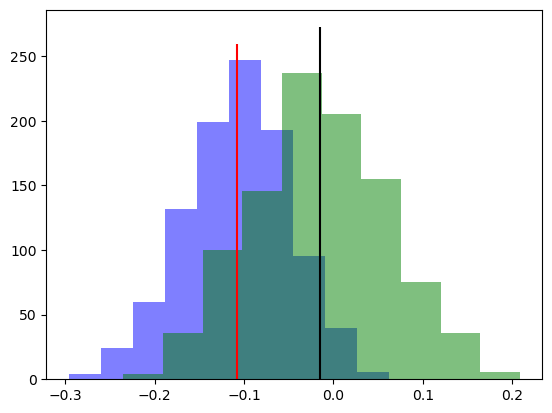

In [104]:
X = mixed_batch_data_zscored[social_cols1]
y = mixed_batch_data_zscored[subt_param_cols]  # predict curve fit params

y = y.values
X = X.values

true_r_all = []
true_p_all = []
scr_r_all = []
scr_p_all = []
for i in range(1000):
    X_train, X_test, y_train, y_test = train_test_split(X, y) # 75-25 split by default

    pls = PLSRegression(n_components=X_train.shape[1])
    pls.fit(X_train, y_train)
    predicted = pls.predict(X_test)
    r, p = pearsonr(predicted.flatten(), y_test.flatten())
    true_r_all.append(r)
    true_p_all.append(p)

    np.random.shuffle(y_train)
    pls = PLSRegression(n_components=X_train.shape[1])
    pls.fit(X_train, y_train)
    predicted = pls.predict(X_test)
    # predicted.shape, y_test.shape
    r,p = pearsonr(predicted.flatten(), y_test.flatten())
    scr_r_all.append(r)
    scr_p_all.append(p)

plt.hist(true_r_all, color = 'b', alpha = 0.5)
plt.hist(scr_r_all, color = 'g', alpha = 0.5)

plt.vlines(np.mean(true_r_all), 0, plt.gca().get_ylim()[1], color='r')
plt.vlines(np.mean(scr_r_all), 0, plt.gca().get_ylim()[1], color= 'k')

print('Paired t-test:', stats.ttest_rel(true_r_all, scr_r_all))

p_val = (np.sum(np.array(scr_r_all) >= np.nanmean(np.array(true_r_all))) + 1) / (n_perm + 1)
p_val